**Chapter-4 Classification Question-13**


In [7]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# CSV file 
weekly = pd.read_csv("C:/Users/DELL/Desktop/ALL CSV FILES - 2nd Edition/weekly.csv")


In [8]:
weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


**a-)
Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?**

In [9]:
weekly.describe(include='all')

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Up
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,605
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899,NaN
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927,NaN
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000,NaN
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000,NaN
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000,NaN
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000,NaN


**Answer:
By using the descibe it give me the information about the count in each column.
Unique values count(for categorical column only).
Top gives result for most occured values(for categorical column only).
Freq shows the count of top(for catgorical column only).**

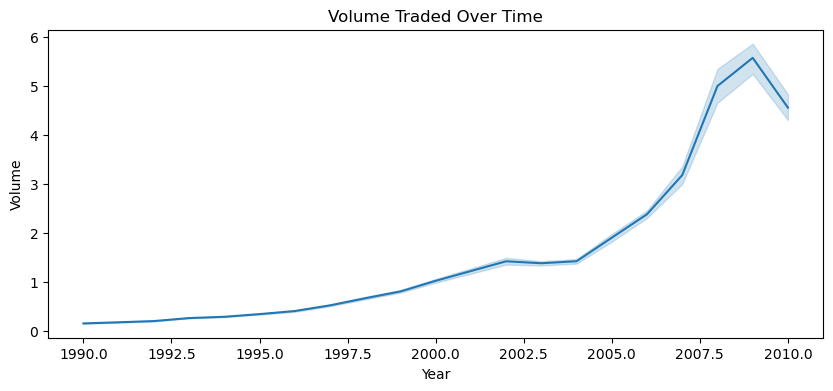

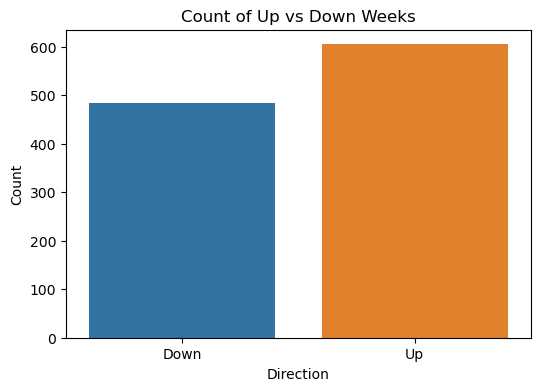

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Line Plot: Volume over years
plt.figure(figsize=(10, 4))
sns.lineplot(data=weekly, x='Year', y='Volume')
plt.title('Volume Traded Over Time')
plt.xlabel('Year')
plt.ylabel('Volume')
plt.show()

# 2. Count Plot: Direction count
plt.figure(figsize=(6, 4))
sns.countplot(data=weekly, x='Direction')
plt.title('Count of Up vs Down Weeks')
plt.xlabel('Direction')
plt.ylabel('Count')
plt.show()

# 3. Correlation Heatmap (only for numeric variables)
#plt.figure(figsize=(10, 6))
#sns.heatmap(weekly.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
#plt.title('Correlation Heatmap of Numeric Features')
#plt.show()


**Answer
The line graph shows that over the year the volume of the trades increases.
The bar plot show the count of down and up.**

**b-)
Use the full data set to perform a logistic regression with
Direction as the response and thefifve lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to be statistically signifcant? If so,c*****nes?

In [11]:
import statsmodels.api as sm

# Convert 'Direction' column to binary (Up=1, Down=0)
weekly['Direction_bin'] = weekly['Direction'].map({'Up': 1, 'Down': 0})

# Select predictors
X = weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]

# Add constant term for intercept
X = sm.add_constant(X)

# Response variable
y = weekly['Direction_bin']

# Fit logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the summary
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Wed, 11 Jun 2025   Pseudo R-squ.:                0.006580
Time:                        10:31:17   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

**Answer:
From above we know that LLR p-value is  greater then 0.05 which means the logistic regression is not significant.
Secondly we notice lag2 predictor is significant because it has less p value then others.**

**c-)
Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regressio**n.

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict probabilities of "Up" (class 1)
pred_probs = result.predict(X)

# Convert probabilities to class predictions (threshold = 0.5)
pred_class = np.where(pred_probs > 0.5, 1, 0)

# Actual classes
actual_class = y.values

# Compute confusion matrix
cm = confusion_matrix(actual_class, pred_class)
print("Confusion Matrix:\n", cm)

# Calculate overall accuracy
accuracy = np.mean(pred_class == actual_class)
print(f"Overall fraction of correct predictions (accuracy): {accuracy:.4f}")


Confusion Matrix:
 [[ 54 430]
 [ 48 557]]
Overall fraction of correct predictions (accuracy): 0.5611


**Answer:
The logistic regression model makes accurate predictions about the market going Up (high recall), but struggles with identifying when it will go Down (very high false positive rate). This leads to low overall accuracy (56.1%), suggesting that the model is biased toward predicting Up, even when the market actually goes Down.**

**d-)Now ft the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 an*****0).


In [13]:
c

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
Confusion Matrix on test data:
 [[ 9 34]
 [ 5 56]]
Overall fraction of correct predictions (accuracy) on test data: 0.6250


**Answer:
Overall 62% accuracy of the model.The precission is low because it is doing wrong prediction for up.**

**e-)Repeat (d) using LDA.**

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# Prepare training and test data as before
train = weekly[weekly['Year'] <= 2008]
test = weekly[weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']

X_test = test[['Lag2']]
y_test = test['Direction']

# Initialize and fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict on test data
y_pred = lda.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (LDA) on test data:\n", cm)

# Compute accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Overall fraction of correct predictions (accuracy) with LDA on test data: {accuracy:.4f}")

Confusion Matrix (LDA) on test data:
 [[ 9 34]
 [ 5 56]]
Overall fraction of correct predictions (accuracy) with LDA on test data: 0.6250


**Answer:
LDA and logistic regression gave identically same result because Lag2 is likely linearly separable to some degree, both models learn similar boundaries.**

**f-)
Repeat (d) using QDA.**

In [15]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
train = weekly[weekly['Year'] <= 2008]
test = weekly[weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']

X_test = test[['Lag2']]
y_test = test['Direction']

# Initialize and fit QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Predict on test data
y_pred = qda.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (QDA) on test data:\n", cm)

# Compute accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Overall fraction of correct predictions (accuracy) with QDA on test data: {accuracy:.4f}")

Confusion Matrix (QDA) on test data:
 [[ 0 43]
 [ 0 61]]
Overall fraction of correct predictions (accuracy) with QDA on test data: 0.5865


**Answer:
The result of the QDA is biased it only covers the up and not down.**

**(g) Repeat (d) using KNN with K = 1.**

In [16]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Prepare training and test data as before
train = weekly[weekly['Year'] <= 2008]
test = weekly[weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']

X_test = test[['Lag2']]
y_test = test['Direction']

# Initialize KNN with K=1
knn = KNeighborsClassifier(n_neighbors=1)

# Fit KNN on training data
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (KNN, K=1) on test data:\n", cm)

# Compute accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Overall fraction of correct predictions (accuracy) with KNN (K=1) on test data: {accuracy:.4f}")


Confusion Matrix (KNN, K=1) on test data:
 [[22 21]
 [30 31]]
Overall fraction of correct predictions (accuracy) with KNN (K=1) on test data: 0.5096


**Answer:
Knn is better then QDA as this is covering both the classes although the acuracy is less but covering both classes.**

**h-)
Repeat (d) using naive Bayes.**

In [17]:
from sklearn.naive_bayes import GaussianNB


# Prepare training and test data as before
train = weekly[weekly['Year'] <= 2008]
test = weekly[weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']

X_test = test[['Lag2']]
y_test = test['Direction']

# Initialize and fit Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict on test data
y_pred = nb.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Naive Bayes) on test data:\n", cm)

# Compute accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Overall fraction of correct predictions (accuracy) with Naive Bayes on test data: {accuracy:.4f}")


Confusion Matrix (Naive Bayes) on test data:
 [[ 0 43]
 [ 0 61]]
Overall fraction of correct predictions (accuracy) with Naive Bayes on test data: 0.5865


**Answer:
naive bayes also bias and do not cover the down as QDA and have the same accuracy**

**i-)
Which of these methods appears to provide the best results on
this data?**

***Answer:
Logistic Regression and LDA tie for the best overall accuracy (62.5%).

Both have some trouble predicting "Down" days correctly (only 9 true negatives), but have fewer false negatives (only 5), meaning they detect "Up" days better.

QDA and Naive Bayes both completely fail to predict any "Down" days correctly (0 true negatives), misclassifying all downs as ups, which is not ideal.

KNN has the most balanced confusion matrix but the lowest accuracy (about 51%), meaning it’s more random or noisy in predictions.

So the best performing methods here are Logistic Regression and LDA, with:
The highest accuracy (62.5%),

And better balance between types of errors compared to QDA, Naive Bayes, or KNN.***

**j-)Experiment with diferent combinations of predictors, including possible transformations and interactions, for each of the
methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held
out data. Note that you should also experiment with values for
K in the KNN classif**er.

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

# Convert 'Direction' to binary
weekly['Direction_bin'] = weekly['Direction'].map({'Up': 1, 'Down': 0})

# Train/test split
train = weekly[weekly['Year'] <= 2008]
test = weekly[weekly['Year'] > 2008]

X_train_base = train[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y_train = train['Direction']
y_train_bin = train['Direction_bin']
X_test_base = test[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y_test = test['Direction']
y_test_bin = test['Direction_bin']

# Try different combinations and models
results = []

combinations = [
    ['Lag2'],
    ['Lag1', 'Lag2'],
    ['Lag2', 'Lag2_squared'],
    ['Lag2', 'Volume'],
    ['Lag1', 'Lag2', 'Lag3'],
    ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5'],
    ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
]

for combo in combinations:
    # Add polynomial term if needed
    X_train = X_train_base.copy()
    X_test = X_test_base.copy()
    if 'Lag2_squared' in combo:
        X_train['Lag2_squared'] = X_train['Lag2'] ** 2
        X_test['Lag2_squared'] = X_test['Lag2'] ** 2

    X_train_combo = X_train[combo]
    X_test_combo = X_test[combo]

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combo)
    X_test_scaled = scaler.transform(X_test_combo)

    # Logistic Regression
    logit = LogisticRegression()
    logit.fit(X_train_scaled, y_train_bin)
    pred_log = logit.predict(X_test_scaled)
    acc_log = accuracy_score(y_test_bin, pred_log)
    cm_log = confusion_matrix(y_test_bin, pred_log)
    results.append(('Logistic', combo, acc_log, cm_log))

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_combo, y_train)
    pred_lda = lda.predict(X_test_combo)
    acc_lda = accuracy_score(y_test, pred_lda)
    cm_lda = confusion_matrix(y_test, pred_lda)
    results.append(('LDA', combo, acc_lda, cm_lda))

    # QDA
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X_train_combo, y_train)
    pred_qda = qda.predict(X_test_combo)
    acc_qda = accuracy_score(y_test, pred_qda)
    cm_qda = confusion_matrix(y_test, pred_qda)
    results.append(('QDA', combo, acc_qda, cm_qda))

    # KNN with different k
    for k in [1, 3, 5, 10]:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, y_train)
        pred_knn = knn.predict(X_test_scaled)
        acc_knn = accuracy_score(y_test, pred_knn)
        cm_knn = confusion_matrix(y_test, pred_knn)
        results.append((f'KNN (k={k})', combo, acc_knn, cm_knn))

# Show top 5 results
sorted_results = sorted(results, key=lambda x: x[2], reverse=True)

print("Top 5 models:")
for model, combo, acc, cm in sorted_results[:5]:
    print(f"\nModel: {model}\nVariables: {combo}\nAccuracy: {acc:.4f}\nConfusion Matrix:\n{cm}")

Top 5 models:

Model: Logistic
Variables: ['Lag2']
Accuracy: 0.6250
Confusion Matrix:
[[ 9 34]
 [ 5 56]]

Model: LDA
Variables: ['Lag2']
Accuracy: 0.6250
Confusion Matrix:
[[ 9 34]
 [ 5 56]]

Model: Logistic
Variables: ['Lag2', 'Lag2_squared']
Accuracy: 0.6250
Confusion Matrix:
[[ 8 35]
 [ 4 57]]

Model: QDA
Variables: ['Lag2', 'Lag2_squared']
Accuracy: 0.6250
Confusion Matrix:
[[ 7 36]
 [ 3 58]]

Model: LDA
Variables: ['Lag2', 'Lag2_squared']
Accuracy: 0.6154
Confusion Matrix:
[[ 7 36]
 [ 4 57]]


**Answer:using LDA accuracy regressed.
QDA accurraccy improved
logistic have same accuracy**

ValueError: shapes (104,6) and (2,) not aligned: 6 (dim 1) != 2 (dim 0)